# 📊 Análise de Curvas GFET - Workflow Modular

Este notebook demonstra o uso dos scripts modulares para análise de curvas GFET:
- **dataprep.py**: Processamento de dados (Raw → Silver)
- **plot_utils.py**: Funções de plotagem reutilizáveis

In [1]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Importar nossos módulos
from dataprep import DataPreparation, DataLoader, processar_experimento, carregar_experimento
from plot_utils import PlotterGFET

print("✅ Módulos importados com sucesso!")

/home/v/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/v/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✅ Módulos importados com sucesso!


## 1️⃣ Preparação dos Dados (Raw → Silver)

Processar arquivos CSV brutos e salvar na camada silver

In [9]:
# Definir caminhos
PASTA_RAW = "/home/v/Documents/contas/chulha/data/bronze/GFETS/19abr/19abr_curves"  # Onde estão os CSVs originais
PASTA_SILVER = "/home/v/Documents/contas/chulha/data/silver/19abr/19abr_curves"  # Onde salvar processados

# Criar preparador de dados
prep = DataPreparation(
    pasta_raw=PASTA_RAW,
    pasta_silver=PASTA_SILVER,
    skiprows=16,        # Pular primeiras 16 linhas
    linha_inicio=9574,  # Início do recorte (última corrida)
    linha_fim=10074     # Fim do recorte
)

# Listar arquivos disponíveis
arquivos = prep.listar_arquivos_csv()
print(f"📂 Encontrados {len(arquivos)} arquivos CSV")
print(f"Primeiros 5: {arquivos[:5]}")

📂 Encontrados 31 arquivos CSV
Primeiros 5: ['C1 - 185pico.csv', 'C1 - 1ato.csv', 'C1 - 1fento.csv', 'C1 - 1pico.csv', 'C2 - BLANK3.csv']


In [ ]:
# ✅ PROCESSAR TODOS OS ARQUIVOS E SALVAR NA SILVER
# Descomente a linha abaixo para processar todos os arquivos de uma vez:
resultados = prep.processar_todos(verbose=True)

# Isso irá:
# 1. Ler cada CSV da pasta RAW
# 2. Aplicar os ajustes (skiprows, recorte de linhas)
# 3. Salvar na pasta SILVER com sufixo "_ajustado.csv"

print(f"\n✅ Processamento concluído! {len(resultados)} arquivos salvos em {PASTA_SILVER}")

# OU processar apenas um arquivo específico para testar:
# if arquivos:
#     caminho = os.path.join(PASTA_RAW, arquivos[0])
#     df = prep.processar_arquivo(caminho, verbose=True)
#     print(f"Preview dos dados:\n{df.head()}")

📊 Encontrados 31 arquivos CSV
📂 Pasta origem: /home/v/Documents/contas/chulha/data/bronze/GFETS/19abr/19abr_curves
📂 Pasta destino: /home/v/Documents/contas/chulha/data/silver/19abr/19abr_curves

 📂 Processando: C1 - 185pico.csv
🔍 Antes do ajuste: 10,058 linhas | 21 colunas
------------------------------------------------------------
✅ Após o ajuste: 484 linhas | 21 colunas
------------------------------------------------------------
📁 Arquivo salvo com sucesso! ✅
📍 Local: /home/v/Documents/contas/chulha/data/silver/19abr/19abr_curves/C1 - 185pico_ajustado.csv

 📂 Processando: C1 - 1ato.csv
🔍 Antes do ajuste: 10,058 linhas | 21 colunas
------------------------------------------------------------
✅ Após o ajuste: 484 linhas | 21 colunas
------------------------------------------------------------
📁 Arquivo salvo com sucesso! ✅
📍 Local: /home/v/Documents/contas/chulha/data/silver/19abr/19abr_curves/C1 - 1ato_ajustado.csv

 📂 Processando: C1 - 1fento.csv
🔍 Antes do ajuste: 10,058 linhas |

## 2️⃣ Carregar Dados Processados (Silver)

Carregar dados já processados para análise

In [12]:
# Criar loader
loader = DataLoader(PASTA_SILVER)

# Listar chips disponíveis
chips = loader.listar_chips_disponiveis()
print(f"🔬 Chips disponíveis: {chips}")

🔬 Chips disponíveis: ['C1', 'C2', 'C3', 'C4', 'C5']


In [13]:
# Selecionar chip para análise
CHIP = chips[0] if chips else "C1"
print(f"📊 Analisando chip: {CHIP}")

# Carregar dados do chip
dados = loader.carregar_chip(CHIP)

# Ver etapas carregadas
print(f"\n📋 Etapas carregadas: {list(dados.keys())}")

# Ver devices disponíveis
devices = loader.obter_colunas_disponiveis(dados)
print(f"🎯 Devices disponíveis: {devices}")

📊 Analisando chip: C1
✅ C1 - 1ato_ajustado.csv carregado como 'menos18'
✅ C1 - 1fento_ajustado.csv carregado como 'menos15'
✅ C1 - 1pico_ajustado.csv carregado como 'menos12'
✅ C1 - 185pico_ajustado.csv carregado como 'c25ng'

📊 Total de etapas carregadas: 4

📋 Etapas carregadas: ['menos18', 'menos15', 'menos12', 'c25ng']
🎯 Devices disponíveis: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']


## 3️⃣ Visualização de Dados

Usar plot_utils para criar gráficos

In [15]:
# Criar plotter
plotter = PlotterGFET(chip_name=CHIP)

### 📈 Curvas de Transferência - Grid Completo

In [17]:
# Plotar grid com todas as curvas de transferência
fig = plotter.plot_curvas_transferencia_grid(
    dados=dados,
    etapas=['bare', 'etoh', 'ddt', 'pbse', 'apt', 'eta'],
    figsize=(20, 16)
)

plt.show()

# Salvar figura (descomente para salvar)
# plotter.salvar_figura(fig, f"resultados/{CHIP}_transferencia_grid.png")

ValueError: Nenhuma etapa disponível nos dados

### 🔄 Curvas Normalizadas - Grid Completo

In [18]:
# Plotar grid com curvas normalizadas
fig = plotter.plot_curvas_normalizadas_grid(
    dados=dados,
    etapas=['bare', 'etoh', 'ddt', 'pbse', 'apt', 'eta'],
    figsize=(20, 16)
)

plt.show()

# Salvar (descomente)
# plotter.salvar_figura(fig, f"resultados/{CHIP}_normalizadas_grid.png")

ValueError: Nenhuma etapa disponível nos dados

### 🎯 Device Individual

In [19]:
# Selecionar device
DEVICE = "1"

# Plotar curva de transferência
fig = plotter.plot_device_individual(
    dados=dados,
    device=DEVICE,
    etapas=['bare', 'etoh', 'ddt', 'pbse', 'apt', 'eta'],
    normalizado=False,
    figsize=(10, 7)
)

plt.show()

ValueError: Device 1 não encontrado em nenhuma etapa

In [20]:
# Plotar curva normalizada
fig = plotter.plot_device_individual(
    dados=dados,
    device=DEVICE,
    etapas=['bare', 'etoh', 'ddt', 'pbse', 'apt', 'eta'],
    normalizado=True,
    figsize=(10, 7)
)

plt.show()

ValueError: Device 1 não encontrado em nenhuma etapa

### 💧 Curvas de Concentração

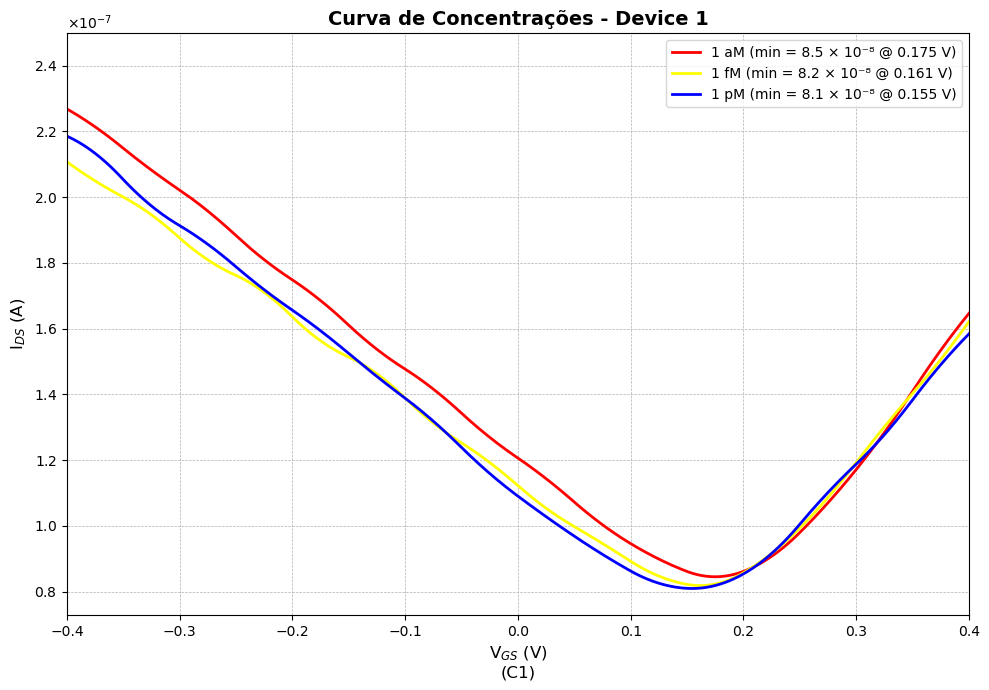

In [21]:
# Plotar curvas de concentração (não normalizado)
fig = plotter.plot_concentracoes(
    dados=dados,
    device=DEVICE,
    concentracoes=['menos18', 'menos15', 'menos12'],
    incluir_branca=True,
    normalizado=False,
    x_range=(-0.4, 0.4),
    figsize=(10, 7)
)

plt.show()

# Salvar (descomente)
# plotter.salvar_figura(fig, f"resultados/{CHIP}_concentracoes_dev{DEVICE}.png")

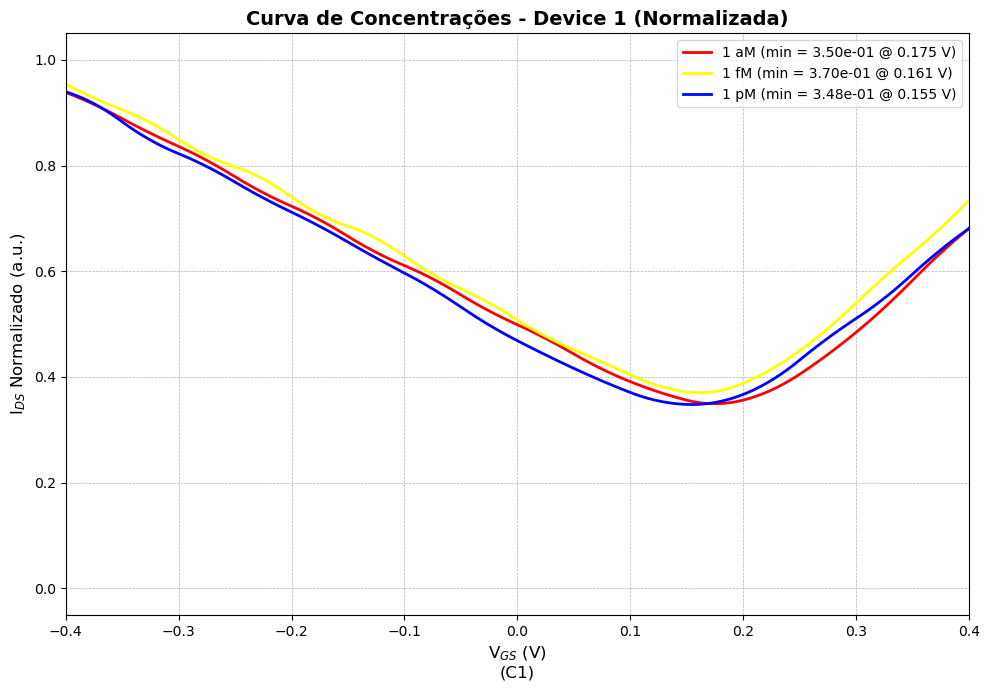

In [22]:
# Plotar curvas de concentração (normalizado)
fig = plotter.plot_concentracoes(
    dados=dados,
    device=DEVICE,
    concentracoes=['menos18', 'menos15', 'menos12'],
    incluir_branca=True,
    normalizado=True,
    x_range=(-0.4, 0.4),
    figsize=(10, 7)
)

plt.show()

# Salvar (descomente)
# plotter.salvar_figura(fig, f"resultados/{CHIP}_concentracoes_norm_dev{DEVICE}.png")

## 4️⃣ Análise Exploratória

Explorar dados de forma interativa

In [23]:
# Exemplo: Ver estatísticas de um device em uma etapa
if 'bare' in dados and '1' in dados['bare'].columns:
    valores = dados['bare']['1']
    
    print("📊 Estatísticas do Device 1 - BARE:")
    print(f"  • Mínimo: {valores.min():.2e} A")
    print(f"  • Máximo: {valores.max():.2e} A")
    print(f"  • Média: {valores.mean():.2e} A")
    print(f"  • Desvio padrão: {valores.std():.2e} A")

In [24]:
# Calcular média dos BLANKs
b_avg = plotter.calcular_media_blanks(dados)

if b_avg is not None:
    print("✅ Média dos BLANKs calculada com sucesso")
    print(f"   Shape: {b_avg.shape}")
    print(f"   Colunas: {list(b_avg.columns)[:5]}...")

## 5️⃣ Exportar Resultados

Salvar múltiplos gráficos

In [25]:
# Criar pasta de resultados
import os
pasta_resultados = f"resultados/{CHIP}"
os.makedirs(pasta_resultados, exist_ok=True)

print(f"📁 Pasta de resultados: {pasta_resultados}")

📁 Pasta de resultados: resultados/C1


In [26]:
# Salvar gráficos para todos os devices (descomente para executar)
"""
for device in devices[:5]:  # Primeiros 5 devices
    try:
        # Curva de transferência
        fig = plotter.plot_device_individual(dados, device, normalizado=False)
        plotter.salvar_figura(fig, f"{pasta_resultados}/transferencia_dev{device}.png")
        plt.close(fig)
        
        # Curva normalizada
        fig = plotter.plot_device_individual(dados, device, normalizado=True)
        plotter.salvar_figura(fig, f"{pasta_resultados}/normalizada_dev{device}.png")
        plt.close(fig)
        
        # Concentrações
        fig = plotter.plot_concentracoes(dados, device, normalizado=True)
        plotter.salvar_figura(fig, f"{pasta_resultados}/concentracoes_dev{device}.png")
        plt.close(fig)
        
        print(f"✅ Gráficos salvos para device {device}")
    except Exception as e:
        print(f"❌ Erro no device {device}: {e}")

print("✅ Exportação concluída!")
"""

'\nfor device in devices[:5]:  # Primeiros 5 devices\n    try:\n        # Curva de transferência\n        fig = plotter.plot_device_individual(dados, device, normalizado=False)\n        plotter.salvar_figura(fig, f"{pasta_resultados}/transferencia_dev{device}.png")\n        plt.close(fig)\n        \n        # Curva normalizada\n        fig = plotter.plot_device_individual(dados, device, normalizado=True)\n        plotter.salvar_figura(fig, f"{pasta_resultados}/normalizada_dev{device}.png")\n        plt.close(fig)\n        \n        # Concentrações\n        fig = plotter.plot_concentracoes(dados, device, normalizado=True)\n        plotter.salvar_figura(fig, f"{pasta_resultados}/concentracoes_dev{device}.png")\n        plt.close(fig)\n        \n        print(f"✅ Gráficos salvos para device {device}")\n    except Exception as e:\n        print(f"❌ Erro no device {device}: {e}")\n\nprint("✅ Exportação concluída!")\n'

---

## 📝 Notas

- **dataprep.py**: Lê CSVs brutos, ajusta linhas/colunas, salva em silver
- **plot_utils.py**: Funções reutilizáveis para plotagem
- Os dados processados ficam em `silver/` e podem ser reutilizados
- Ajuste os parâmetros (`skiprows`, `linha_inicio`, `linha_fim`) conforme seu experimento